## Lab 02: Q-Learning on Gridworld

Lab01 đã implement **Multi-Armed Bandit (MAB)** và **ε-greedy MAB** — các agent chỉ cập nhật giá trị dựa trên trạng thái hiện tại, không quan tâm đến future reward.

Lab02 implement **Q-Learning**, một thuật toán RL đầy đủ sử dụng **Bellman equation**:

$$Q(s, a) \leftarrow Q(s, a) + \alpha \left[ r + \gamma \max_{a'} Q(s', a') - Q(s, a) \right]$$

- $\alpha$: learning rate  
- $\gamma$: discount factor (đánh giá tầm quan trọng của future reward)
- So với MAB: Q-Learning *nhìn trước* — giá trị cập nhật theo reward tương lai kỳ vọng

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 1. Môi trường Gridworld (tái sử dụng từ Lab01)

In [2]:
class environment:
    def __init__(self, grid_height, grid_width):
        self.height = grid_height
        self.width = grid_width
        self.start = []
        self.end = []
        self.reward = []
        self.map = np.array([i for i in range(grid_height * grid_width)])
        self.action_space = [0, 1, 2, 3]

    def get_Map(self):
        print(self.map.reshape([self.width, self.height]))

    def get_NumState(self):
        return self.height * self.width

    def map_Designate(self, start_cell, end_cell, reward):
        self.start.append(start_cell)
        self.end.append(end_cell)
        self.reward.append(reward)

    def get_Observation(self, location, action):
        if location in self.start:
            idx = self.start.index(location)
            return self.end[idx], self.action_space, self.reward[idx]

        reward = 0
        if action == 0:    # UP
            new_location = location if location - self.width < 0 else location - self.width
        elif action == 1:  # DOWN
            new_location = location if location + self.width > self.height * self.width - 1 else location + self.width
        elif action == 2:  # LEFT
            new_location = location if location % self.width == 0 else location - 1
        elif action == 3:  # RIGHT
            new_location = location if (location + 1) % self.width == 0 else location + 1
        return new_location, self.action_space, reward

# Tạo gridworld 8x8 giống Lab01
Envir = environment(8, 8)
Envir.get_Map()
for s, e, r in [(17,56,-15),(18,56,-15),(19,56,-15),(21,56,-15),(25,56,-15),
                (33,56,-15),(41,56,-15),(42,56,-15),(43,56,-15),(46,56,-15),
                (47,56,-15),(47,56,-15),(15,56,+15),(1,10,+5),(26,56,+20)]:
    Envir.map_Designate(s, e, r)

[[ 0  1  2  3  4  5  6  7]
 [ 8  9 10 11 12 13 14 15]
 [16 17 18 19 20 21 22 23]
 [24 25 26 27 28 29 30 31]
 [32 33 34 35 36 37 38 39]
 [40 41 42 43 44 45 46 47]
 [48 49 50 51 52 53 54 55]
 [56 57 58 59 60 61 62 63]]


## 2. Q-Learning Agent

**Điểm khác biệt so với MAB (Lab01):**
- MAB cập nhật: `Q(s,a) += (1/count) * (r - Q(s,a))` — chỉ dùng immediate reward
- Q-Learning cập nhật: `Q(s,a) += α * (r + γ * max_a' Q(s',a') - Q(s,a))` — dùng cả future reward

In [3]:
class QLearning_agent:
    def __init__(self, envir, init_location, alpha=0.1, gamma=0.9, epsilon=0.3):
        """
        alpha   : learning rate
        gamma   : discount factor — tầm quan trọng của future reward
        epsilon : xác suất explore ngẫu nhiên (epsilon-greedy)
        """
        self.envir = envir
        self.location_now = init_location
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon

        self.reward_trace = []
        self.lastState = None
        self.lastAction = None

        # Q-table: {state: [Q(s,0), Q(s,1), Q(s,2), Q(s,3)]}
        num_states = envir.get_NumState()
        num_actions = len(envir.action_space)
        self.Q = np.zeros((num_states, num_actions))

    def get_TotalReward(self):
        return np.sum(self.reward_trace)

    def getAction(self, observation):
        self.location_now, action_space, pre_reward = observation

        # Cập nhật Q-table theo Bellman equation
        if pre_reward is not None:
            self.reward_trace.append(pre_reward)
            s  = self.lastState
            a  = self.lastAction
            s_ = self.location_now
            # Q(s,a) += α * [r + γ * max_a' Q(s',a') - Q(s,a)]
            td_target = pre_reward + self.gamma * np.max(self.Q[s_])
            self.Q[s, a] += self.alpha * (td_target - self.Q[s, a])

        # Epsilon-greedy action selection
        if np.random.rand() < self.epsilon:
            action = np.random.choice(action_space)
        else:
            action = int(np.argmax(self.Q[self.location_now]))

        self.lastState = self.location_now
        self.lastAction = action
        return action

## 3. Chạy Q-Learning Agent

In [4]:
init_location = 0
num_iter = 1000
log_freq = 100

ql_agent = QLearning_agent(envir=Envir, init_location=init_location,
                           alpha=0.1, gamma=0.9, epsilon=0.3)

data_ql = []
for i in range(num_iter):
    if i == 0:
        obs = (init_location, Envir.action_space, None)
    else:
        obs = Envir.get_Observation(location=ql_agent.location_now, action=chosen_action)

    chosen_action = ql_agent.getAction(observation=obs)

    if (i + 1) % log_freq == 0:
        aver = np.mean(ql_agent.reward_trace) if ql_agent.reward_trace else 0
        data_ql.append(aver)
        print(f'iter: {i+1}\t Total reward: {ql_agent.get_TotalReward():.1f}\t Average: {aver:.4f}')

print(f'\nTotal reward (Q-Learning): {ql_agent.get_TotalReward()}')

iter: 100	 Total reward: 5.0	 Average: 0.0505
iter: 200	 Total reward: 35.0	 Average: 0.1759
iter: 300	 Total reward: 85.0	 Average: 0.2843
iter: 400	 Total reward: 55.0	 Average: 0.1378
iter: 500	 Total reward: 100.0	 Average: 0.2004
iter: 600	 Total reward: 185.0	 Average: 0.3088
iter: 700	 Total reward: 205.0	 Average: 0.2933
iter: 800	 Total reward: 195.0	 Average: 0.2441
iter: 900	 Total reward: 265.0	 Average: 0.2948
iter: 1000	 Total reward: 335.0	 Average: 0.3353

Total reward (Q-Learning): 335


## 4. So sánh Q-Learning với MAB và ε-greedy MAB (từ Lab01)

In [5]:
# ---- MAB agent (greedy, từ Lab01) ----
class MAB_agent:
    def __init__(self, envir, init_location):
        self.reward_trace = []
        self.location_now = init_location
        self.lastAction = None
        self.lastState = None
        self.value_table = {}

    def get_TotalReward(self):
        return np.sum(self.reward_trace)

    def getAction(self, observation):
        self.location_now, action_space, pre_reward = observation
        if self.location_now not in self.value_table:
            self.value_table[self.location_now] = {i: [0, 1] for i in action_space}
        if pre_reward is None:
            action = np.random.choice(action_space)
        else:
            self.reward_trace.append(pre_reward)
            v = self.value_table[self.lastState][self.lastAction][0]
            c = self.value_table[self.lastState][self.lastAction][1]
            c += 1
            v += (1/c) * (pre_reward - v)
            self.value_table[self.lastState][self.lastAction] = [v, c]
            vals = np.array([self.value_table[self.lastState][a][0] for a in action_space])
            action = int(np.argmax(vals))
        self.lastState = self.location_now
        self.lastAction = action
        return action

# ---- MABe agent (epsilon-greedy, từ Lab01) ----
class MABe_agent(MAB_agent):
    def __init__(self, envir, init_location, epsilon):
        super().__init__(envir, init_location)
        self.epsilon = epsilon

    def getAction(self, observation):
        self.location_now, action_space, pre_reward = observation
        if self.location_now not in self.value_table:
            self.value_table[self.location_now] = {i: [0, 1] for i in action_space}
        toss = np.random.rand()
        if pre_reward is None or toss < self.epsilon:
            action = np.random.choice(action_space)
        else:
            self.reward_trace.append(pre_reward)
            v = self.value_table[self.lastState][self.lastAction][0]
            c = self.value_table[self.lastState][self.lastAction][1]
            c += 1
            v += (1/c) * (pre_reward - v)
            self.value_table[self.lastState][self.lastAction] = [v, c]
            vals = np.array([self.value_table[self.lastState][a][0] for a in action_space])
            action = int(np.argmax(vals))
        self.lastState = self.location_now
        self.lastAction = action
        return action

# ---- Chạy cả 3 agent với cùng số bước ----
def run_agent(agent_obj, envir, init_loc, num_iter, log_freq):
    data = []
    chosen = None
    for i in range(num_iter):
        if i == 0:
            obs = (init_loc, envir.action_space, None)
        else:
            obs = envir.get_Observation(location=agent_obj.location_now, action=chosen)
        chosen = agent_obj.getAction(obs)
        if (i + 1) % log_freq == 0:
            aver = np.mean(agent_obj.reward_trace) if agent_obj.reward_trace else 0
            data.append(aver)
    return data

num_iter = 1000
log_freq = 100
init_loc = 0

mab   = MAB_agent(Envir, init_loc)
mabe  = MABe_agent(Envir, init_loc, epsilon=0.5)
ql    = QLearning_agent(Envir, init_loc, alpha=0.1, gamma=0.9, epsilon=0.3)

data_mab  = run_agent(mab,  Envir, init_loc, num_iter, log_freq)
data_mabe = run_agent(mabe, Envir, init_loc, num_iter, log_freq)
data_ql2  = run_agent(ql,   Envir, init_loc, num_iter, log_freq)

print(f"Total reward — MAB:          {mab.get_TotalReward():.1f}")
print(f"Total reward — ε-greedy MAB: {mabe.get_TotalReward():.1f}")
print(f"Total reward — Q-Learning:   {ql.get_TotalReward():.1f}")

Total reward — MAB:          0.0
Total reward — ε-greedy MAB: -225.0
Total reward — Q-Learning:   260.0


## 5. Trực quan hóa: Average Reward qua thời gian

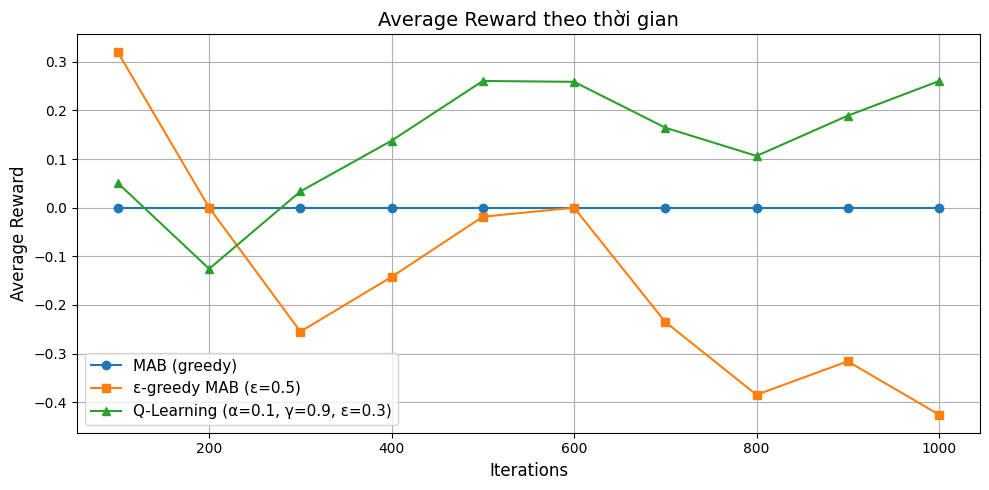

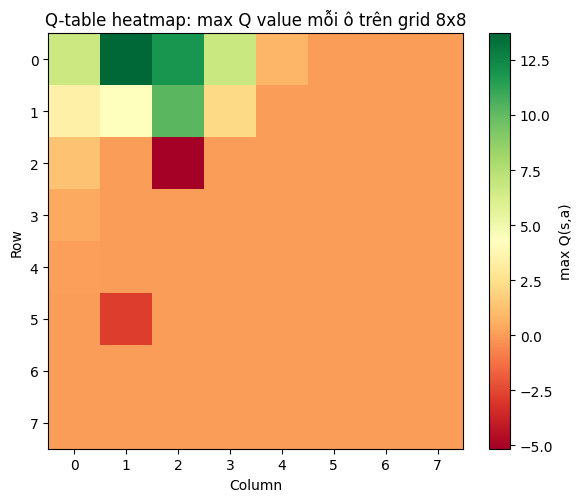

In [6]:
x_axis = list(range(log_freq, num_iter + 1, log_freq))

plt.figure(figsize=(10, 5))
plt.plot(x_axis, data_mab,  label='MAB (greedy)',       marker='o')
plt.plot(x_axis, data_mabe, label='ε-greedy MAB (ε=0.5)', marker='s')
plt.plot(x_axis, data_ql2,  label='Q-Learning (α=0.1, γ=0.9, ε=0.3)', marker='^')
plt.title('Average Reward theo thời gian', fontsize=14)
plt.xlabel('Iterations', fontsize=12)
plt.ylabel('Average Reward', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True)
plt.tight_layout()
plt.show()

# Vẽ Q-table dưới dạng heatmap (max Q value mỗi ô)
best_q = np.max(ql.Q, axis=1).reshape(8, 8)
plt.figure(figsize=(6, 5))
plt.imshow(best_q, cmap='RdYlGn')
plt.colorbar(label='max Q(s,a)')
plt.title('Q-table heatmap: max Q value mỗi ô trên grid 8x8', fontsize=12)
plt.xlabel('Column')
plt.ylabel('Row')
plt.tight_layout()
plt.show()